<a href="https://www.kaggle.com/code/sagorkumarmitra/audio-models-on-hugging-face?scriptVersionId=222729669" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [2]:
audio_path = '/kaggle/input/audio-mp3/example.mp3'

In [3]:
y, sr = librosa.load(audio_path,sr=None)

In [4]:
type(y)

numpy.ndarray

In [5]:
y.shape

(630031,)

In [6]:
sr

48000

In [7]:
y

array([-0.05220421, -0.06220762, -0.04791953, ...,  0.        ,
        0.        ,  0.        ], dtype=float32)

Text(0, 0.5, 'Amplitudes')

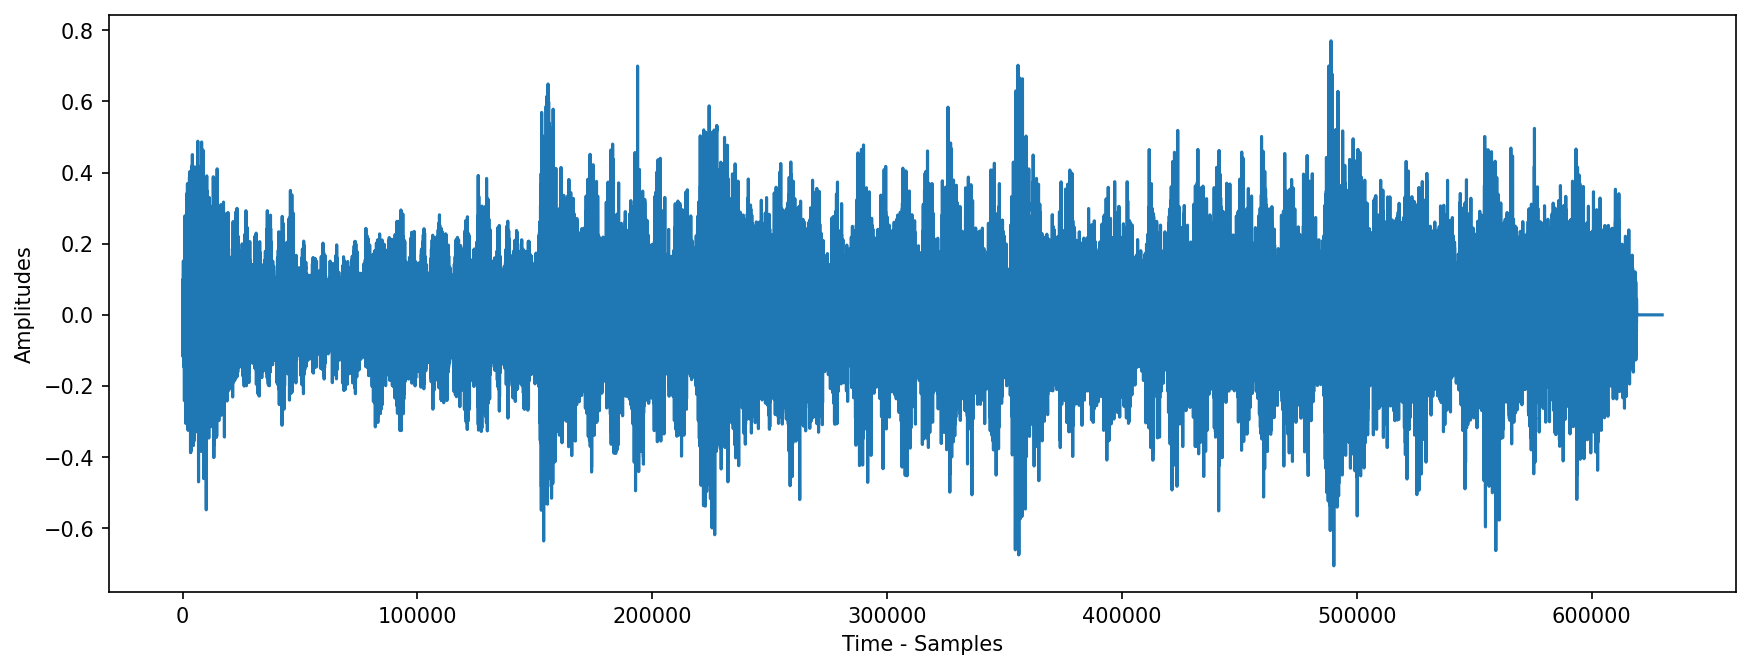

In [8]:
plt.figure(figsize=(14,5),dpi=150)
plt.plot(y)
plt.xlabel('Time - Samples')
plt.ylabel('Amplitudes')

In [9]:
from IPython.display import Audio

In [10]:
Audio(data=y,rate=sr)

In [11]:
# DFT  - Discrete Fourier Transform
window = np.hanning(len(y))
windowed_input = y*window
dft = np.fft.rfft(windowed_input)

In [12]:
dft

array([ 2.20216033e+01+0.00000000e+00j, -1.53848612e+01-7.83757079e+00j,
        3.68769589e-01-1.47522648e+01j, ...,
       -5.86705934e-05+1.48828988e-04j, -7.31754172e-05-9.04516761e-05j,
        7.56536829e-05-7.11123768e-05j])

In [13]:
type(dft)

numpy.ndarray

In [14]:
amplitude = np.abs(dft)
amplitude_db = librosa.amplitude_to_db(amplitude,ref=np.max)
frequency = librosa.fft_frequencies(sr=sr,n_fft=len(y))

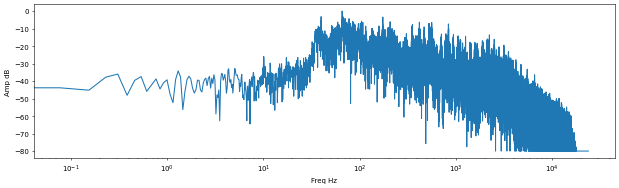

In [15]:
plt.figure(figsize=(15,4), dpi=50)
plt.plot(frequency,amplitude_db)
plt.xlabel('Freq Hz')
plt.ylabel('Amp dB')
plt.xscale('log')

In [16]:
D = librosa.stft(y)
D_db = librosa.amplitude_to_db(np.abs(D),ref=np.max)

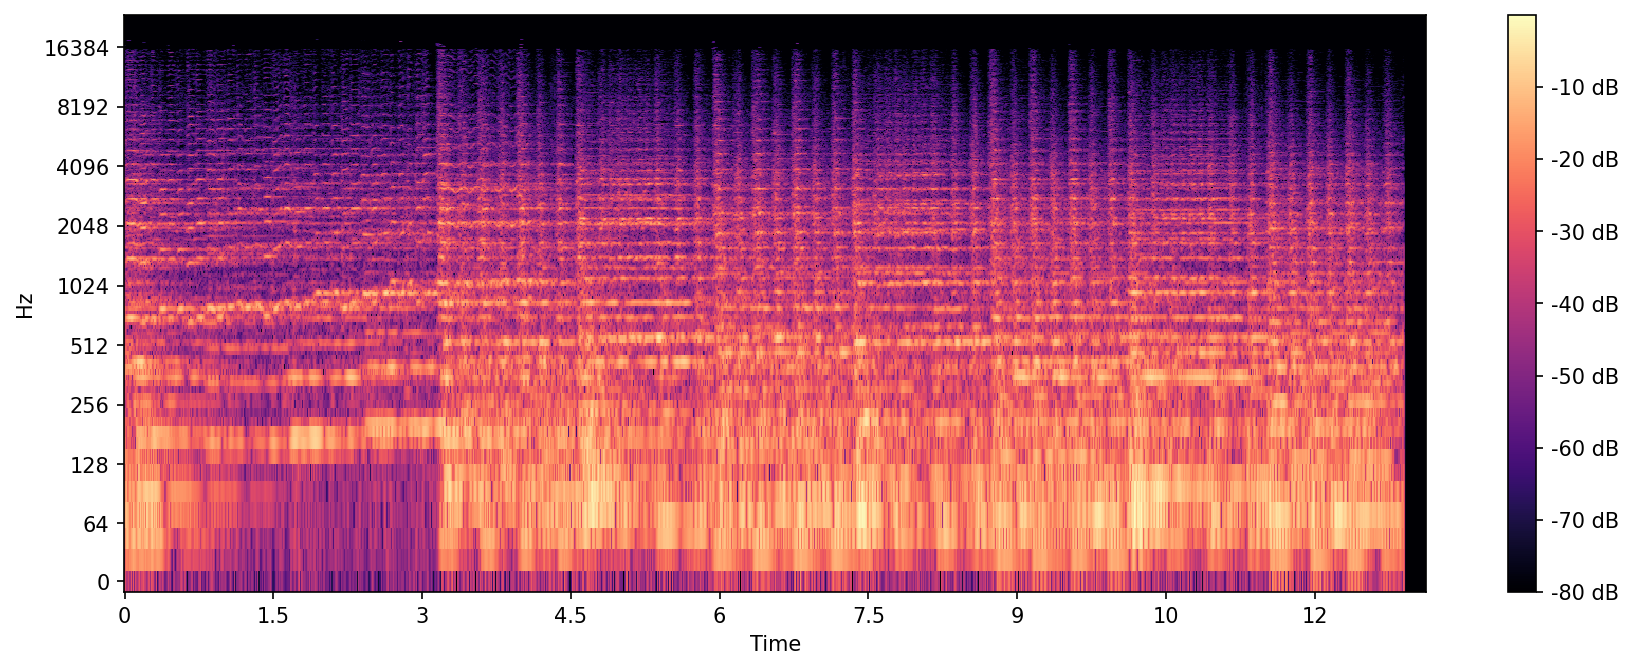

In [17]:
plt.figure(figsize=(14,5),dpi=150)
librosa.display.specshow(D_db,sr=sr,x_axis='time',y_axis='log')
plt.colorbar(format='%+2.0f dB')

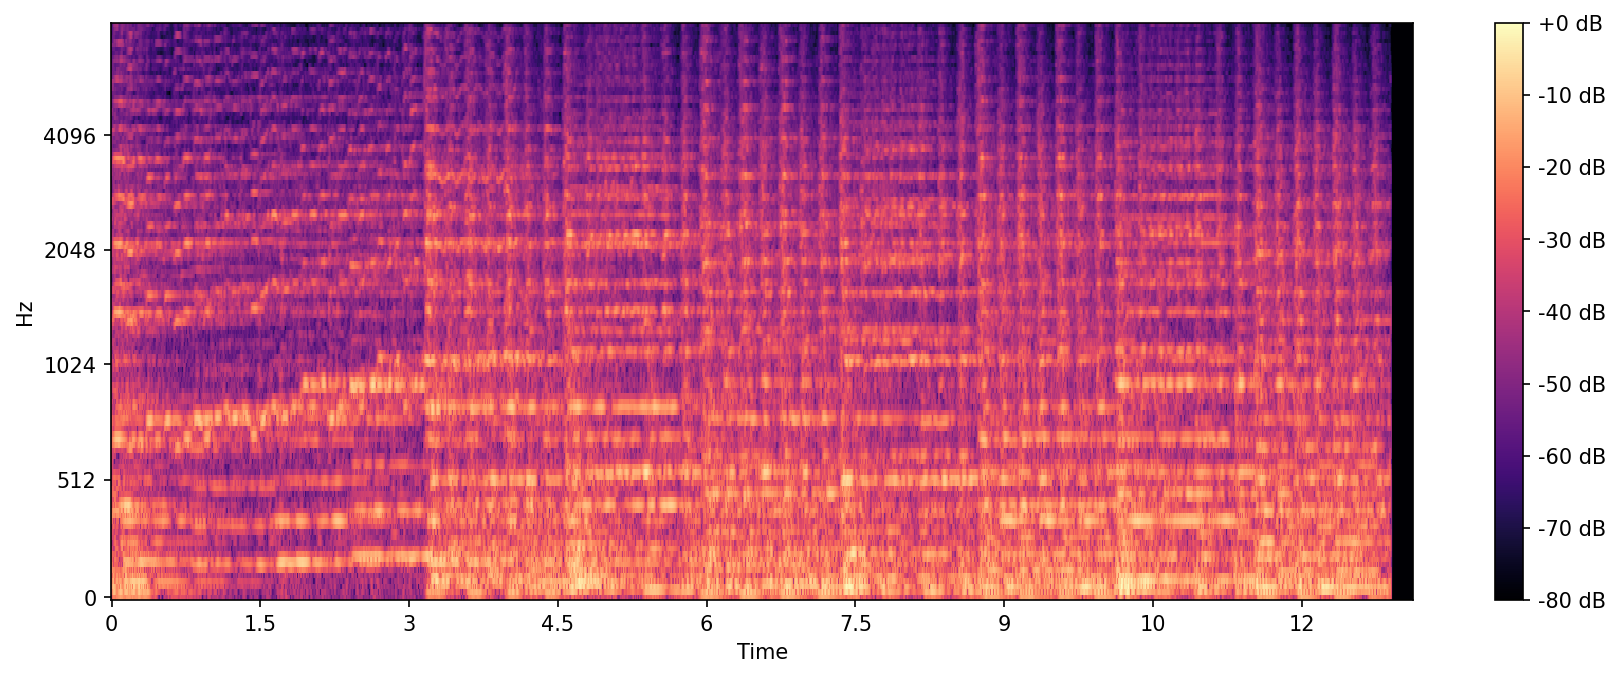

In [18]:
S = librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128,fmax=8000)
S_dB = librosa.power_to_db(S,ref=np.max)

plt.figure(figsize=(14,5),dpi=150)
librosa.display.specshow(S_dB,x_axis='time',y_axis='mel',sr=sr,fmax=8000)
plt.colorbar(format='%+2.0f dB')

In [19]:
import torch, torchaudio, transformers

In [20]:
torch.__version__

'2.5.1+cu121'

In [21]:
from transformers import AutoFeatureExtractor, ASTForAudioClassification

In [22]:
sr

48000

In [23]:
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [24]:
y

array([-0.05220421, -0.06220762, -0.04791953, ...,  0.        ,
        0.        ,  0.        ], dtype=float32)

In [25]:
result = feature_extractor(y,return_tensors='pt')

It is strongly recommended to pass the `sampling_rate` argument to this function. Failing to do so can result in silent errors that might be hard to debug.


In [26]:
result

{'input_values': tensor([[[ 0.0770, -0.2676,  0.1092,  ..., -1.2776, -1.2776, -1.2776],
         [ 0.0846, -0.2771,  0.0997,  ..., -1.2776, -1.2776, -1.2776],
         [-0.2939, -0.3674,  0.0095,  ..., -1.2776, -1.2776, -1.2776],
         ...,
         [ 0.2184, -0.0845,  0.2923,  ..., -1.2776, -1.2776, -1.2776],
         [ 0.1963, -0.1293,  0.2475,  ..., -1.2776, -1.2776, -1.2776],
         [-0.0509, -0.4521, -0.0752,  ..., -1.2776, -1.2776, -1.2776]]])}

In [27]:
model = ASTForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [28]:
result['input_values']

tensor([[[ 0.0770, -0.2676,  0.1092,  ..., -1.2776, -1.2776, -1.2776],
         [ 0.0846, -0.2771,  0.0997,  ..., -1.2776, -1.2776, -1.2776],
         [-0.2939, -0.3674,  0.0095,  ..., -1.2776, -1.2776, -1.2776],
         ...,
         [ 0.2184, -0.0845,  0.2923,  ..., -1.2776, -1.2776, -1.2776],
         [ 0.1963, -0.1293,  0.2475,  ..., -1.2776, -1.2776, -1.2776],
         [-0.0509, -0.4521, -0.0752,  ..., -1.2776, -1.2776, -1.2776]]])

In [29]:
prediction_logits = model(result['input_values']).logits

In [30]:
prediction_logits

tensor([[ -5.9081,  -9.2253,  -9.4442,  -9.4990, -10.3686,  -9.8169, -10.5372,
          -9.9140, -11.0119, -11.1294, -10.8732, -11.3651, -12.3890, -11.9322,
         -10.1947, -10.5203, -10.9214, -11.4615, -11.2874, -10.9701, -11.3812,
         -11.1792, -10.5879, -10.7083,  -9.4158, -11.2141, -10.9959,  -8.1345,
          -8.3063, -12.1890,  -8.9141,  -8.1373,  -9.5586, -10.1567, -10.2660,
         -11.6801, -10.3482, -10.8475, -10.4001, -10.8535, -11.0698,  -9.5788,
         -12.0086, -10.2645, -10.1869, -10.8037, -10.6147, -10.8702, -11.1633,
         -11.6032, -12.3197, -11.4073, -10.7273, -10.6266, -10.7189, -10.2813,
         -12.3984, -10.6907, -11.4477, -10.8104, -12.4599, -10.8371, -11.6523,
         -11.1756,  -8.7801,  -9.1707, -11.2029, -10.2863, -11.8267,  -9.5817,
         -10.8891, -11.8293,  -7.8608,  -8.4752,  -9.2617, -10.5787, -10.6426,
         -10.5211,  -9.6369, -11.0325,  -9.8193,  -9.8407, -11.3109, -10.0102,
          -9.1413, -11.3183,  -9.6363, -10.5181, -10

In [31]:
predicted_class_ids = torch.argmax(prediction_logits,dim=-1).item()

In [32]:
predicted_class_ids

137

In [33]:
model.config.id2label

{0: 'Speech',
 1: 'Male speech, man speaking',
 2: 'Female speech, woman speaking',
 3: 'Child speech, kid speaking',
 4: 'Conversation',
 5: 'Narration, monologue',
 6: 'Babbling',
 7: 'Speech synthesizer',
 8: 'Shout',
 9: 'Bellow',
 10: 'Whoop',
 11: 'Yell',
 12: 'Battle cry',
 13: 'Children shouting',
 14: 'Screaming',
 15: 'Whispering',
 16: 'Laughter',
 17: 'Baby laughter',
 18: 'Giggle',
 19: 'Snicker',
 20: 'Belly laugh',
 21: 'Chuckle, chortle',
 22: 'Crying, sobbing',
 23: 'Baby cry, infant cry',
 24: 'Whimper',
 25: 'Wail, moan',
 26: 'Sigh',
 27: 'Singing',
 28: 'Choir',
 29: 'Yodeling',
 30: 'Chant',
 31: 'Mantra',
 32: 'Male singing',
 33: 'Female singing',
 34: 'Child singing',
 35: 'Synthetic singing',
 36: 'Rapping',
 37: 'Humming',
 38: 'Groan',
 39: 'Grunt',
 40: 'Whistling',
 41: 'Breathing',
 42: 'Wheeze',
 43: 'Snoring',
 44: 'Gasp',
 45: 'Pant',
 46: 'Snort',
 47: 'Cough',
 48: 'Throat clearing',
 49: 'Sneeze',
 50: 'Sniff',
 51: 'Run',
 52: 'Shuffle',
 53: 'Walk